In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision import transforms

In [3]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Load the image and apply transformations
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)


def load_images(directory_root):
    image_list, label_list = [], []
    print("[INFO] Loading images...")

    for disease_folder in os.listdir(directory_root):
        disease_folder_path = os.path.join(directory_root, disease_folder)
        if not os.path.isdir(disease_folder_path):
            continue

        for img_name in os.listdir(disease_folder_path):
            if img_name.startswith("."):
                continue
            img_path = os.path.join(disease_folder_path, img_name)
            if img_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_list.append(img_path)
                label_list.append(disease_folder)
    
    print("[INFO] Image loading completed")
    print(f"Total images: {len(image_list)}")
    return image_list, label_list

In [4]:
# Load images and labels
directory_root = r"C:\Users\Anshika Jain\OneDrive\Desktop\plant disease\PlantVillage"
image_paths, labels = load_images(directory_root)

# Encode labels as integers
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Train, validation, and test splits
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels_encoded, test_size=0.3, random_state=42, stratify=labels_encoded
)
valid_paths, test_paths, valid_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(valid_paths)}")
print(f"Test samples: {len(test_paths)}")

[INFO] Loading images...
[INFO] Image loading completed
Total images: 20638
Training samples: 14446
Validation samples: 3096
Test samples: 3096


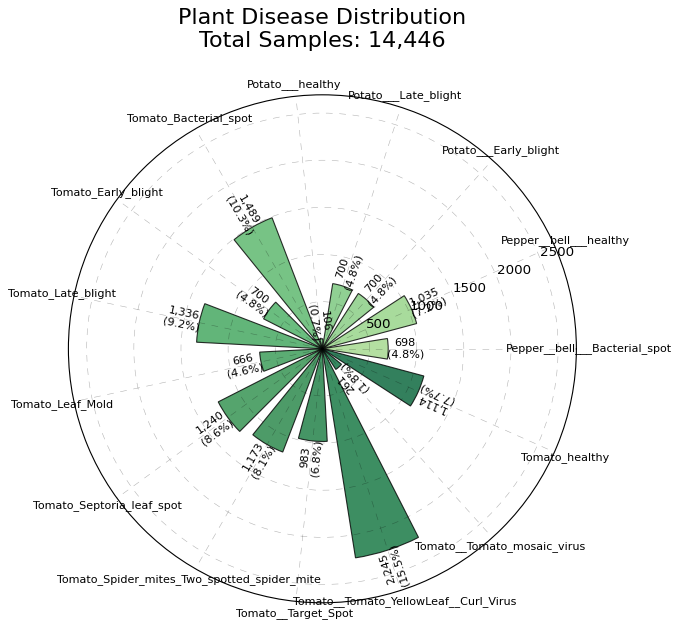

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def visualize_class_distribution(labels, class_names):
    class_counts = Counter(labels)
    sorted_counts = sorted(class_counts.items(), key=lambda x: x[0])
    counts = [count for _, count in sorted_counts]
    class_labels = [class_names[idx] for idx, _ in sorted_counts]
    percentages = [count/len(labels)*100 for count in counts]
    
    plt.figure(figsize=(10,8))
    ax = plt.subplot(111, projection='polar')
    angles = np.linspace(0, 2*np.pi, len(counts), endpoint=False)
    colors = plt.cm.YlGn(np.linspace(0.4, 0.9, len(counts)))
    bars = ax.bar(angles, counts, width=2*np.pi/len(counts)*0.75, alpha=0.8, color=colors)
    
    for angle, count, percentage in zip(angles, counts, percentages):
        label_radius = count + (max(counts) * 0.08)
        label = f'{count:,}\n({percentage:.1f}%)'
        ax.text(angle, label_radius, label, ha='center', va='center', fontsize=10,
                rotation=np.degrees(angle) if -90 <= np.degrees(angle) <= 90 else np.degrees(angle) + 180)
    
    ax.set_title('Plant Disease Distribution\nTotal Samples: {:,}'.format(sum(counts)), y=1.05, fontsize=20, pad=20)
    ax.set_xticks(angles)
    ax.set_xticklabels(class_labels, fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(counts) * 1.2)
    plt.tight_layout()
    plt.show()

plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
visualize_class_distribution(train_labels, label_encoder.classes_)

In [6]:
# Data Transformations
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),           # Data augmentation for training
    transforms.RandomRotation(10),              # Random rotation for variability
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

valid_test_transform = transforms.Compose([
    transforms.Resize((128,128)),              # Consistent resizing for validation/test
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Same normalization as training
])

# Create datasets with appropriate transformations
train_dataset = PlantDiseaseDataset(train_paths, train_labels, transform=train_transform)
valid_dataset = PlantDiseaseDataset(valid_paths, valid_labels, transform=valid_test_transform)
test_dataset = PlantDiseaseDataset(test_paths, test_labels, transform=valid_test_transform)

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.2361221].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.4365578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.3406973].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.4191287].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.3590205].


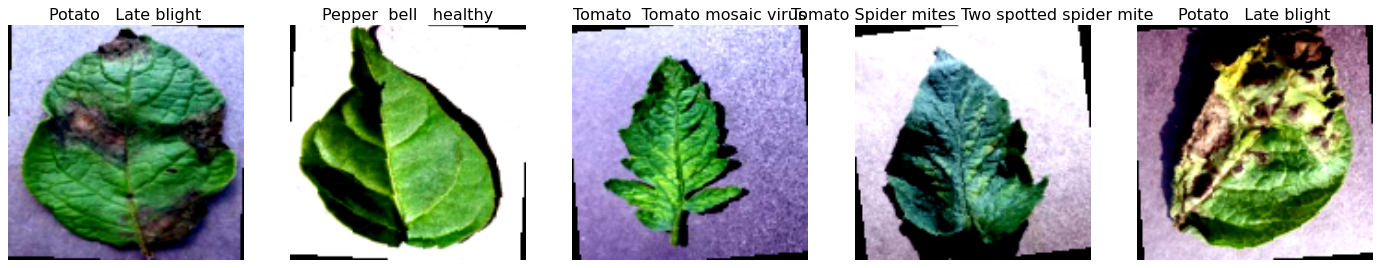

In [7]:

def visualize_samples(dataset, num_samples=5):
    plt.figure(figsize=(22, 5))
    for i in range(num_samples):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5  # De-normalize
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(label_encoder.inverse_transform([label])[0].replace('_',' '))  # Convert label back to class name
        plt.axis('off')
    plt.show()

visualize_samples(train_dataset)

In [8]:
for inputs, labels in test_loader:
    print(f"Batch inputs shape: {inputs.shape}")  # Should be [batch_size, 3, 128, 128]
    print(f"Batch labels shape: {labels.shape}")  # Should be [batch_size]
    print(f"First 5 samples labels: {labels[:5]}")   # Print first 5 labels
    break

Batch inputs shape: torch.Size([64, 3, 128, 128])
Batch labels shape: torch.Size([64])
First 5 samples labels: tensor([11,  2, 14, 12, 11])


In [9]:
class PlantDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseModel, self).__init__()
        # Convolutional Block 1
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding="same"),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Output: 32x128x128 (assuming input is 3x256x256)
        )
        # Convolutional Block 2
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding="same"),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Output: 64x64x64
        )
        # Convolutional Block 3
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding="same"),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Output: 128x32x32
        )
        # Convolutional Block 4
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding="same"),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Output: 256x16x16
        )
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # Output: 256x1x1
        # Fully Connected Layers
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),  # Adjusted input size after GAP
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.global_avg_pool(x)
        x = self.fc_block(x)
        return x

In [10]:
# Initialize model, loss, optimizer
num_classes = len(label_encoder.classes_)
print(f"Number of Classes: {num_classes}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device Used: {device}")

model = PlantDiseaseModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.002)

Number of Classes: 15
Device Used: cpu


In [11]:
from torchsummary import summary
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
      BatchNorm2d-10          [-1, 128, 32, 32]             256
             ReLU-11          [-1, 128, 32, 32]               0
        MaxPool2d-12          [-1, 128, 16, 16]               0
           Conv2d-13          [-1, 256, 16, 16]         295,168
      BatchNorm2d-14          [-1, 256,

In [12]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0, save_path="best_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)  # Save the best model
            print(f"[INFO] Model checkpoint saved to {self.save_path}")
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print("[INFO] Early stopping triggered.")
                return True
        return False

def evaluate_model(model, data_loader, criterion):
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss /= len(data_loader)
    accuracy = correct / total * 100
    return val_loss, accuracy

In [13]:
def train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs, early_stopping=None):
    train_losses, valid_losses, valid_accuracies = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(enumerate(train_loader), desc=f"Epoch {epoch+1}/{epochs}", total=len(train_loader))

        for batch_idx, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix({"Train Loss": loss.item()})

        # Record training loss
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation step
        val_loss, val_accuracy = evaluate_model(model, valid_loader, criterion)
        valid_losses.append(val_loss)
        valid_accuracies.append(val_accuracy)

        # Print epoch summary
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_accuracy:.2f}%")

        # Early stopping
        if early_stopping and early_stopping(val_loss, model):
            print("[INFO] Early stopping triggered.")
            break

    return train_losses, valid_losses, valid_accuracies

In [16]:
n_epochs = 100

early_stopping = EarlyStopping(patience=3, min_delta=0.1, save_path="best_model.pth")
train_losses, valid_losses, valid_accuracies = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=n_epochs, early_stopping=early_stopping
)

Epoch 1/100: 100%|██████████| 226/226 [09:22<00:00,  2.49s/it, Train Loss=1.78]


Epoch 1: Train Loss = 1.8646, Val Loss = 1.7357, Val Accuracy = 48.90%
[INFO] Model checkpoint saved to best_model.pth


Epoch 2/100: 100%|██████████| 226/226 [08:48<00:00,  2.34s/it, Train Loss=1.57]


Epoch 2: Train Loss = 1.7434, Val Loss = 1.6030, Val Accuracy = 53.88%
[INFO] Model checkpoint saved to best_model.pth


Epoch 3/100: 100%|██████████| 226/226 [08:56<00:00,  2.37s/it, Train Loss=1.66]


...

Epoch 11: Train Loss = 1.1042, Val Loss = 1.0060, Val Accuracy = 68.18%


Epoch 12/100: 100%|██████████| 226/226 [05:54<00:00,  1.57s/it, Train Loss=0.888]


Epoch 12: Train Loss = 1.0679, Val Loss = 0.9476, Val Accuracy = 70.70%


Epoch 13/100: 100%|██████████| 226/226 [05:46<00:00,  1.53s/it, Train Loss=1.38] 


Epoch 13: Train Loss = 1.0210, Val Loss = 0.8965, Val Accuracy = 72.42%
[INFO] Early stopping triggered.
[INFO] Early stopping triggered.


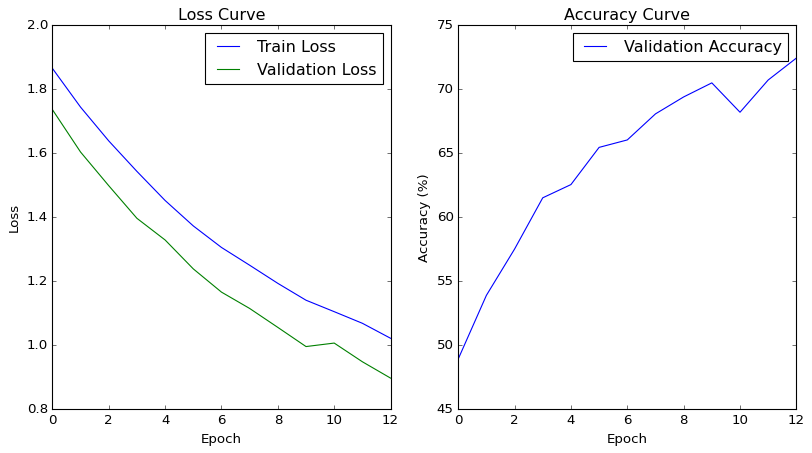

In [17]:
def plot_learning_curve(train_losses, valid_losses, valid_accuracies):
    plt.figure(figsize=(12, 6))

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(valid_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy curve
    plt.subplot(1, 2, 2)
    plt.plot(valid_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.show()

plot_learning_curve(train_losses, valid_losses, valid_accuracies)

In [18]:
# Load the best model
model.load_state_dict(torch.load("best_model.pth"))
print("[INFO] Best model loaded for final evaluation.")

final_val_loss, final_val_accuracy = evaluate_model(model, test_loader, criterion)
print(f"Final Evaluation -> Val Loss: {final_val_loss:.4f}, Val Accuracy: {final_val_accuracy:.2f}%")

[INFO] Best model loaded for final evaluation.
Final Evaluation -> Val Loss: 0.9832, Val Accuracy: 70.83%
